# Mohanna Miri 9th project 1405/6/13

## Logistic Regression From Scratch

### 1.Importing libraries


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

np.random.seed(42)
%matplotlib inline

### 2.Class Designing (LogisticReressionFromScratch)

- `__init__` : setting hyperparameters(`learning-rate` & `epochs`)
- `_sigmoid` : sigmiod activation function(`0<sigmoid<1`)
- `_binary_cross_entropy` : calculating cost function
- `fit` : training Model by descent gradient
- `predict_proba` : predicting the probability(`between 0 and 1`)
- `predict` : Predicting the final label using a threshold of `0.5`

In [4]:
class LogisticRegressionFromScratch:

    """1"""
    def __init__(self, learning_rate: float = 0.01, epochs: int = 1000) -> None:
        
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights : np.ndarray | None = None
        self.bias : float = 0.0
        self.loss_history : list[float] = []


    """2""" 
    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray: 
        """z is an array and sigmoid turn them to array of 0<-<1"""
        z = np.clip(z ,-500 ,500)  #numerical stability
        return 1.0 / (1.0 + np.exp(-z))


    """3 BCE"""
    @staticmethod
    def _binary_cross_entropy(y_true:np.ndarray , y_pred:np.ndarray) -> float:  #kind of loss 

        epsilon = 1e-15 #avoid log(0)
        y_pred = np.clip(y_pred, epsilon , 1-epsilon) #ta daghigha 0 ya 1 nashavad.
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1- y_pred))
        return float(loss)


    """4"""
    def fit(self, X:np.ndarray , y:np.ndarray) -> "LogisticRegressionFromScratch":
    
        n_samples , n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.epochs):
            #forward pass
            linear_output = X @ self.weights + self.bias 
            y_pred = self._sigmoid(linear_output)  #self.method() def=method

            #track loss for this epoch
            loss = self._binary_cross_entropy(y , y_pred)
            self.loss_history.append(loss)

            #Compute Gradient (vectorized , no loops over samples!)
            error = y_pred - y
            dw = (1 / n_samples) * (X.T @ error) #gradient weight
            db = (1 / n_samples) * np.sum(error) #gradient bias 

            #Update the w , b 
            self.weights -= dw * self.learning_rate
            self.bias -= db * self.learning_rate

        return self

    """5"""
    def predict_proba(self , X:np.ndarray) -> np.ndarray:
        # probability is between 0 and 1 (like 0.78)
        linear_output = X @ self.weights + self.bias 
        return  self._sigmoid(linear_output)

    """6"""
    def predict(self, X:np.ndarray , threshold: float = 0.5) -> np.ndarray:
        #predict is 0 or 1
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

### 3.Producing Dataset
We use `make_classification` to generate a two-dimensional, approximately linearly separable dataset for training and evaluating the Logistic Regression model.


In [5]:
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42,
)

X_train , X_test , y_train , y_test = train_test_split(X,y , random_state=42, test_size=0.2)

print(f"Train shape:{X_train.shape} , Test shape:{X_test.shape}")

Train shape:(240, 2) , Test shape:(60, 2)


##### Displaying the data before training

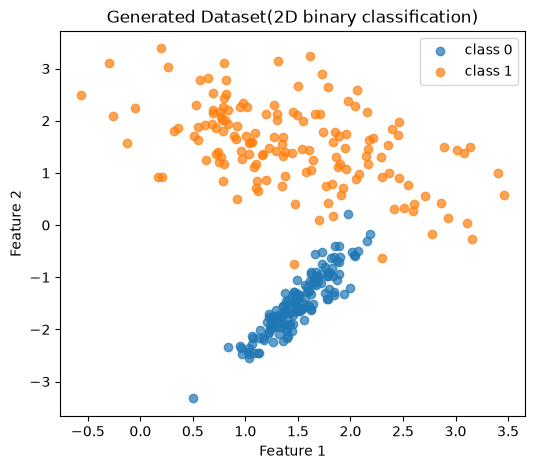

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(X[y==0][:,0], X[y==0][:,1], label="class 0", alpha=0.7)
plt.scatter(X[y==1][:,0], X[y==1][:,1], label="class 1",alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated Dataset(2D binary classification)")
plt.legend()
plt.show()


### 4.Training the Model
Training the model with `learning_rate=0.1` , `epochs=2000`

In [7]:
model = LogisticRegressionFromScratch(learning_rate=0.1, epochs=2000)
model.fit(X_train , y_train)

print(f"Final traning Loss: {model.loss_history[-1]:.4f}")


Final traning Loss: 0.0467


### 5.Loss Curve

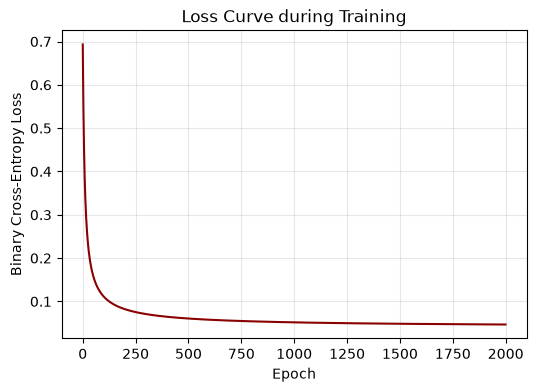

In [8]:
plt.figure(figsize=(6,4))
plt.plot(model.loss_history , color="darkred")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Curve during Training")
plt.grid(alpha=0.3)
plt.show()

### 6.Prediction on Test Data 

In [9]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print("Sample predicted probabilities:", np.round(y_pred_proba[:5], 3)) #predict_proba
print("Sample predicted labels:", y_pred[:5]) #predict
print("True labels:", y_test[:5])

Sample predicted probabilities: [0.007 1.    1.    0.031 1.   ]
Sample predicted labels: [0 1 1 0 1]
True labels: [0 1 1 0 1]


### 7.Model Evaluation from Scratch
The following functions calculate the `Confusion Matrix` and `evaluation metrics` (`Accuracy, Precision, Recall, and F1-Score`) completely from scratch using only `NumPy`.

In [10]:
def confusion_matrix_manual(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Compute the confusion matrix components manually.

    Args:
        y_true: Ground-truth binary labels.
        y_pred: Predicted binary labels.

    Returns:
        A dictionary with counts of True Positives (TP), True Negatives (TN),
        False Positives (FP), and False Negatives (FN).
    """
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    return {"TP": tp, "TN": tn, "FP": fp, "FN": fn}


def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Compute Accuracy, Precision, Recall, and F1-Score manually.

    Args:
        y_true: Ground-truth binary labels.
        y_pred: Predicted binary labels.

    Returns:
        A dictionary containing accuracy, precision, recall, and f1_score.
    """
    cm = confusion_matrix_manual(y_true, y_pred)
    tp, tn, fp, fn = cm["TP"], cm["TN"], cm["FP"], cm["FN"]

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
    }

In [11]:
cm = confusion_matrix_manual(y_test, y_pred)
metrics = classification_metrics(y_test, y_pred)

print("Confusion Matrix:")
print(f"  True Positives (TP):  {cm['TP']}")
print(f"  True Negatives (TN):  {cm['TN']}")
print(f"  False Positives (FP): {cm['FP']}")
print(f"  False Negatives (FN): {cm['FN']}")

print("\nEvaluation Metrics:")
for name, value in metrics.items():
    print(f"  {name.capitalize():10s}: {value:.4f}")

Confusion Matrix:
  True Positives (TP):  31
  True Negatives (TN):  28
  False Positives (FP): 1
  False Negatives (FN): 0

Evaluation Metrics:
  Accuracy  : 0.9833
  Precision : 0.9688
  Recall    : 1.0000
  F1_score  : 0.9841


##### Graphical Representation

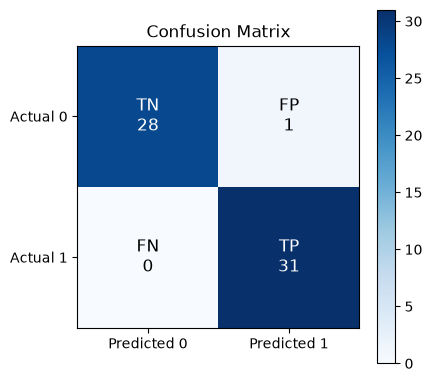

In [12]:
cm_array = np.array([[cm["TN"], cm["FP"]],
                     [cm["FN"], cm["TP"]]])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm_array, cmap="Blues")

labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{cm_array[i, j]}",
                ha="center", va="center", fontsize=12,
                color="white" if cm_array[i, j] > cm_array.max() / 2 else "black")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted 0", "Predicted 1"])
ax.set_yticklabels(["Actual 0", "Actual 1"])
ax.set_title("Confusion Matrix")
plt.colorbar(im)
plt.tight_layout()
plt.show()

### 8.Decision Boundary

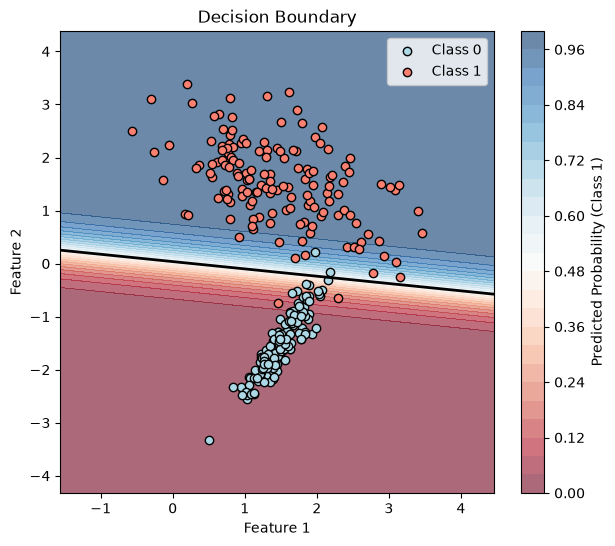

In [13]:
def plot_decision_boundary(model: LogisticRegressionFromScratch,
                            X: np.ndarray, y: np.ndarray) -> None:
    """
    Plot the decision boundary of a trained logistic regression model
    on a 2D dataset.

    Args:
        model: A fitted LogisticRegressionFromScratch instance.
        X: 2D input features, shape (n_samples, 2).
        y: True binary labels, shape (n_samples,).
    """
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid_points).reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, probs, levels=25, cmap="RdBu", alpha=0.6)
    plt.colorbar(label="Predicted Probability (Class 1)")
    # Decision boundary line at probability = 0.5
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)

    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], edgecolor="k",
                label="Class 0", color="lightblue")
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], edgecolor="k",
                label="Class 1", color="salmon")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")
    plt.legend()
    plt.show()


plot_decision_boundary(model, X, y)

### 9.Conclusion

## 9. Conclusion

* The model was successfully trained on two-dimensional data, and the loss decreased steadily, indicating proper convergence of the gradient descent algorithm.

* The evaluation metrics (Accuracy, Precision, Recall, and F1-Score), which were implemented entirely from scratch without using ready-made libraries, demonstrated satisfactory model performance on the test data.

* The plotted decision boundary effectively separates the two classes, which is consistent with the linear nature of the Logistic Regression algorithm.

**Potential Improvements for Future Work:**

* Adding regularization (L1/L2) to reduce the risk of overfitting.

* Implementing Mini-Batch or Stochastic Gradient Descent (SGD) for larger datasets.

* Adding Early Stopping based on the validation loss.
